In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn streamlit


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [5]:
import yfinance as yf

# Download Apple stock data from 2020 to 2023
data = yf.download("AAPL", start="2020-01-01", end="2023-01-01")

# Save the data to a CSV file
data.to_csv("AAPL_stock_data.csv")

# Display the first few rows
print(data.head())

/var/folders/x8/w3v4mrps41zg1v14zz9jl_kw0000gn/T/ipykernel_6029/77306514.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.538513  72.598892  71.292304  71.545890  135480400
2020-01-03  71.833290  72.594055  71.608685  71.765667  146322800
2020-01-06  72.405663  72.444306  70.702997  70.954173  118387200
2020-01-07  72.065155  72.671348  71.845377  72.415345  108872000
2020-01-08  73.224396  73.526287  71.768071  71.768071  132079200


In [6]:
import yfinance as yf

# Download Tesla stock data from 2020 to 2023
tesla_data = yf.download("TSLA", start="2020-01-01", end="2023-01-01")

# Save the data to a CSV file
tesla_data.to_csv("TSLA_stock_data.csv")

# Display the first few rows
print(tesla_data.head())

/var/folders/x8/w3v4mrps41zg1v14zz9jl_kw0000gn/T/ipykernel_6029/1195849333.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla_data = yf.download("TSLA", start="2020-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           TSLA       TSLA       TSLA       TSLA       TSLA
Date                                                             
2020-01-02  28.684000  28.713333  28.114000  28.299999  142981500
2020-01-03  29.534000  30.266666  29.128000  29.366667  266677500
2020-01-06  30.102667  30.104000  29.333332  29.364668  151995000
2020-01-07  31.270666  31.441999  30.224001  30.760000  268231500
2020-01-08  32.809334  33.232666  31.215334  31.580000  467164500


In [4]:
import pandas as pd

# Load the data
tesla_data = pd.read_csv("TSLA_stock_data.csv", index_col="Date", parse_dates=True)
print(tesla_data.head())

ValueError: 'Date' is not in list

In [7]:
import pandas as pd

# Load the data
tesla_data = pd.read_csv("TSLA_stock_data.csv", index_col="Date", parse_dates=True)

# Display the first few rows
print(tesla_data.head())

ValueError: 'Date' is not in list

In [8]:
import pandas as pd

# Load the data with explicit date format
tesla_data = pd.read_csv(
    "TSLA_stock_data.csv",
    index_col="Date",
    parse_dates=["Date"],
    date_format="%Y-%m-%d"  # Specify the date format
)

# Display the first few rows
print(tesla_data.head())

ValueError: Missing column provided to 'parse_dates': 'Date'

In [9]:
print(tesla_data.info())
print(tesla_data.index)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 756 entries, 2020-01-02 to 2022-12-30
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   756 non-null    float64
 1   (High, TSLA)    756 non-null    float64
 2   (Low, TSLA)     756 non-null    float64
 3   (Open, TSLA)    756 non-null    float64
 4   (Volume, TSLA)  756 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 35.4 KB
None
DatetimeIndex(['2020-01-02', '2020-01-03', '2020-01-06', '2020-01-07',
               '2020-01-08', '2020-01-09', '2020-01-10', '2020-01-13',
               '2020-01-14', '2020-01-15',
               ...
               '2022-12-16', '2022-12-19', '2022-12-20', '2022-12-21',
               '2022-12-22', '2022-12-23', '2022-12-27', '2022-12-28',
               '2022-12-29', '2022-12-30'],
              dtype='datetime64[ns]', name='Date', length=756, freq=None)


In [10]:
print(tesla_data.isnull().sum())

Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64


In [13]:
tesla_data.bfill(inplace=True)  

In [17]:
tesla_data['MA_7'] = tesla_data['Close'].rolling(window=7).mean()  # 7-day moving average
tesla_data['MA_30'] = tesla_data['Close'].rolling(window=30).mean()  # 30-day moving average

In [16]:
import pandas as pd

# Ensure 'Close' column is numeric
tesla_data['Close'] = pd.to_numeric(tesla_data['Close'], errors='coerce')

# Fill missing values if necessary
tesla_data['Close'].ffill(inplace=True)

# Calculate moving averages
tesla_data['MA_7'] = tesla_data['Close'].rolling(window=7).mean()
tesla_data['MA_30'] = tesla_data['Close'].rolling(window=30).mean()


TypeError: arg must be a list, tuple, 1-d array, or Series

In [19]:
import pandas as pd

# Convert 'Close' column to numeric
tesla_data['Close'] = pd.to_numeric(tesla_data['Close'], errors='coerce')

# Forward-fill missing values
tesla_data['Close'] = tesla_data['Close'].ffill()

# Calculate moving averages
tesla_data['MA_7'] = tesla_data['Close'].rolling(window=7).mean()
tesla_data['MA_30'] = tesla_data['Close'].rolling(window=30).mean()


TypeError: arg must be a list, tuple, 1-d array, or Series

In [20]:
tesla_data.dropna(inplace=True)

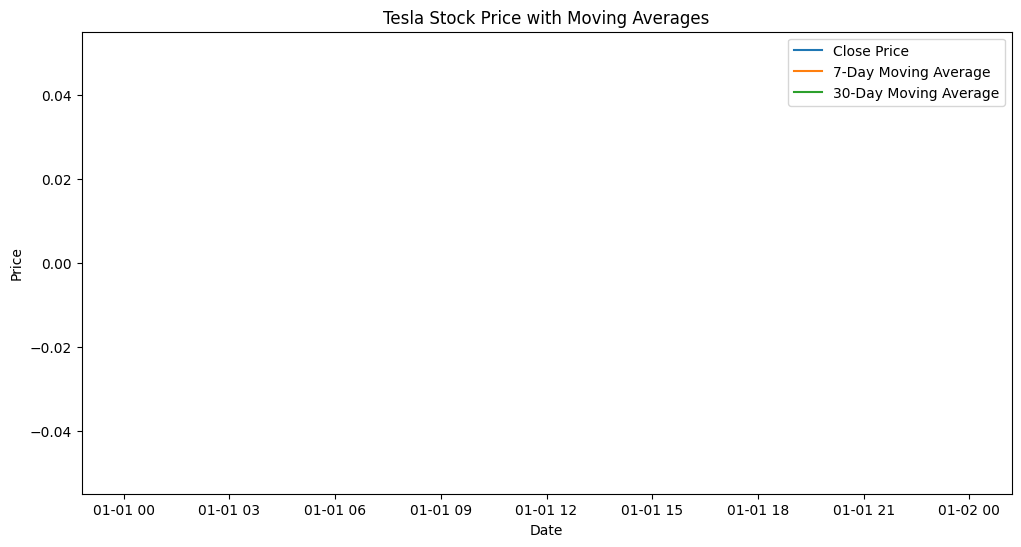

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(tesla_data['Close'], label='Close Price')
plt.plot(tesla_data['MA_7'], label='7-Day Moving Average')
plt.plot(tesla_data['MA_30'], label='30-Day Moving Average')
plt.title("Tesla Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [22]:
# Define features (X) and target (y)
X = tesla_data.drop(columns=['Close'])
y = tesla_data['Close']

In [23]:
from sklearn.model_selection import train_test_split

# Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

ValueError: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [24]:
from sklearn.ensemble import RandomForestRegressor

# Create and train the model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

NameError: name 'X_train' is not defined

In [25]:
# Predict on the test set
y_pred = model.predict(X_test)

NameError: name 'X_test' is not defined

In [26]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"Mean Absolute Error: {mae}")

NameError: name 'y_test' is not defined

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual Price')
plt.plot(y_test.index, y_pred, label='Predicted Price')
plt.title("Actual vs Predicted Tesla Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

NameError: name 'y_test' is not defined

<Figure size 1200x600 with 0 Axes>

In [28]:
!pip install ipywidgets yfinance pandas numpy scikit-learn joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 914.9/914.9 kB 839.6 kB/s  0:00:01eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 973.9 kB/s  0:00:02ta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [ipywidgets]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [29]:
import pandas as pd
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
import joblib

# Download Tesla stock data
tesla_data = yf.download("TSLA", start="2020-01-01", end="2023-01-01")

# Check the column names
print("Original Columns:", tesla_data.columns)

# Flatten the MultiIndex columns correctly
tesla_data.columns = tesla_data.columns.get_level_values(0)  # Extract the first level (price type)

# Check the updated column names
print("Flattened Columns:", tesla_data.columns)

# Feature engineering
tesla_data['MA_7'] = tesla_data['Close'].rolling(window=7).mean()
tesla_data['MA_30'] = tesla_data['Close'].rolling(window=30).mean()
tesla_data['Daily_Return'] = tesla_data['Close'].pct_change()
tesla_data.dropna(inplace=True)

# Define features (X) and target (y)
X = tesla_data.drop(columns=['Close'])
y = tesla_data['Close']

# Print X and y
print("X=", X)
print("\n\n", "y=", y)

# Train a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Save the model
joblib.dump(model, "tesla_stock_predictor_model1.pkl")
print("Model saved as tesla_stock_predictor_model1.pkl")

/var/folders/x8/w3v4mrps41zg1v14zz9jl_kw0000gn/T/ipykernel_6029/1597464880.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla_data = yf.download("TSLA", start="2020-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed


Original Columns: MultiIndex([( 'Close', 'TSLA'),
            (  'High', 'TSLA'),
            (   'Low', 'TSLA'),
            (  'Open', 'TSLA'),
            ('Volume', 'TSLA')],
           names=['Price', 'Ticker'])
Flattened Columns: Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')
X= Price             High         Low        Open     Volume        MA_7  \
Date                                                                    
2020-02-13   54.533333   49.000000   49.456001  394339500   50.939810   
2020-02-14   54.198002   52.366669   52.481335  235405500   51.562000   
2020-02-18   57.333332   55.490665   56.106667  245725500   52.604286   
2020-02-19   62.985332   60.068001   61.566666  381345000   54.217142   
2020-02-20   60.799999   57.329334   60.796665  264523500   55.437428   
...                ...         ...         ...        ...         ...   
2022-12-23  128.619995  121.019997  126.370003  166989700  140.234286   
2022-12-27  119.669998  

In [30]:
import pandas as pd
import yfinance as yf
from sklearn.ensemble import RandomForestRegressor
import joblib

# Download Tesla stock data
tesla_data = yf.download("TSLA", start="2020-01-01", end="2023-01-01")

# Feature engineering
tesla_data['MA_7'] = tesla_data['Close'].rolling(window=7).mean()
tesla_data['MA_30'] = tesla_data['Close'].rolling(window=30).mean()
tesla_data['Daily_Return'] = tesla_data['Close'].pct_change()
tesla_data.dropna(inplace=True)

# Define features (X) and target (y)
X = tesla_data.drop(columns=['Close'])
y = tesla_data['Close']

# Train a Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# Save the model
joblib.dump(model, "tesla_stock_predictor_model1.pkl")
print("Model saved as tesla_stock_predictor_model1.pkl")

/var/folders/x8/w3v4mrps41zg1v14zz9jl_kw0000gn/T/ipykernel_6029/618714272.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  tesla_data = yf.download("TSLA", start="2020-01-01", end="2023-01-01")
[*********************100%***********************]  1 of 1 completed
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Model saved as tesla_stock_predictor_model1.pkl


In [31]:
import pandas as pd
import yfinance as yf
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
import ipywidgets as widgets
from IPython.display import display

# Load the trained model
model = joblib.load("tesla_stock_predictor_model1.pkl")
print(model)
# Create widgets
stock_symbol = widgets.Text(value="TSLA", description="Stock Symbol:")
start_date = widgets.DatePicker(description="Start Date", value=pd.to_datetime("2020-01-01"))
end_date = widgets.DatePicker(description="End Date", value=pd.to_datetime("2023-01-01"))
window_ma = widgets.IntSlider(description="Moving Average Window (Days)", min=7, max=30, value=7)
predict_button = widgets.Button(description="Predict")
output = widgets.Output()

# Function to handle button click
def on_predict_button_click(b):
    with output:
        output.clear_output()  # Clear previous output
        try:
            # Fetch stock data
            data = yf.download(stock_symbol.value, start=start_date.value, end=end_date.value)
            data['MA_7'] = data['Close'].rolling(window=window_ma.value).mean()
            data['MA_30'] = data['Close'].rolling(window=30).mean()
            data['Daily_Return'] = data['Close'].pct_change()
            data.dropna(inplace=True)

            # Prepare features
            X = data.drop(columns=['Close'])
            y_true = data['Close']

            # Make predictions and convert to 1D array
            predictions = model.predict(X)
            print (predictions)

            # Create a DataFrame for predictions
            predictions_df = pd.DataFrame({
                'Date': data.index,
                'Actual Price': y_true,
                'Predicted Price': predictions
            })

            # Display predictions
            print("### Predicted Stock Prices")

            # Show the graph
            print("#### Graph of Predicted vs Actual Prices")
            fig, ax = plt.subplots(figsize=(12, 6))
            ax.plot(predictions_df['Date'], predictions_df['Actual Price'], label='Actual Price', color='blue')
            ax.plot(predictions_df['Date'], predictions_df['Predicted Price'], label='Predicted Price', color='orange')
            ax.set_title(f"{stock_symbol.value} Stock Price Predictions")
            ax.set_xlabel("Date")
            ax.set_ylabel("Price")
            ax.legend()
            plt.show()

            # Show the table
            print("#### Table of Predicted Prices")
            display(predictions_df)

            # Show key statistics
            print("#### Key Statistics")
            print(f"- **Mean Predicted Price**: {predictions_df['Predicted Price'].mean():.2f}")
            print(f"- **Minimum Predicted Price**: {predictions_df['Predicted Price'].min():.2f}")
            print(f"- **Maximum Predicted Price**: {predictions_df['Predicted Price'].max():.2f}")
            print(f"- **Standard Deviation**: {predictions_df['Predicted Price'].std():.2f}")
            print(f"- **Median Predicted Price**: {predictions_df['Predicted Price'].median():.2f}")

            # Model performance metrics
            mae = mean_absolute_error(y_true, predictions)
            r2 = r2_score(y_true, predictions)
            print("#### Model Performance Metrics")
            print(f"- **Mean Absolute Error (MAE)**: {mae:.2f}")
            print(f"- **R² Score**: {r2:.2f}")

            # Model insights
            print("#### Model Insights")
            print("""
            - The model uses historical stock data to predict future prices.
            - The predictions are based on features like moving averages and daily returns.
            - The Mean Absolute Error (MAE) and R² Score indicate the model's accuracy.
            """)

        except Exception as e:
            print(f"An error occurred: {e}")

# Attach the function to the button
predict_button.on_click(on_predict_button_click)

# Display the UI
display(stock_symbol, start_date, end_date, window_ma, predict_button, output)

RandomForestRegressor(random_state=42)


Text(value='TSLA', description='Stock Symbol:')

DatePicker(value=Timestamp('2020-01-01 00:00:00'), description='Start Date', step=1)

DatePicker(value=Timestamp('2023-01-01 00:00:00'), description='End Date', step=1)

IntSlider(value=7, description='Moving Average Window (Days)', max=30, min=7)

Button(description='Predict', style=ButtonStyle())

Output()